# Train 3D CNN Classifier

This notebook trains a simple 3D CNN on the zebrafish tensor dataset using **time as channels**. To avoid leakage, it first builds an unaugmented dataset, then performs the train/validation/holdout split, and only then applies random XY rotation augmentation to the training subset.

In [1]:
%load_ext autoreload
%autoreload 2

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from zebrafish_ml import (
    Zebrafish3DCNNClassifier,
    augment_training_tensors_with_rotations,
    plot_confusion_matrices,
    plot_training_history,
)
from zebrafish_notebook_utils import (
    configure_full_dataframe_display,
    load_compound_image_condition_map_csv,
)
from zebrafish_tensor_utils import (
    build_moa_labeled_tensor_dataset,
    build_tensor_embedding_2d,
    plot_tensor_embedding_2d,
)

warnings.filterwarnings("ignore", message="IProgress not found.*")

In [2]:
configure_full_dataframe_display()
condition_df = load_compound_image_condition_map_csv()
condition_df.shape

(2376, 20)

In [3]:
# User inputs
# selected_mechanisms:
#   list of normalized mechanism names from condition_df["mechanism_of_action"].
#   Use 2 or more classes depending on the comparison you want to study.
#   This default picks two similar pairs:
#   Pair 1: GABAAR_Antagonist vs GABAAR_NegativeAllostericModulator.
#   Pair 2: NMDAR_Activation vs NMDAR_Antagonist.
#   The goal is to create within-pair similarity but between-pair separation.
selected_mechanisms = [
    "GABAAR_Antagonist",
    "GABAAR_NegativeAllostericModulator",
    "NMDAR_Activation",
    "NMDAR_Antagonist",
]
# selected_concentrations:
#   subset of treatment concentration bands to include.
#   Typical options: ["high"], ["mid"], ["low"], or combinations such as ["high", "mid", "low"].
#   Water controls are added separately as class 0 and do not need to be listed here.
selected_concentrations = ["high", "mid", "low"]
# max_compounds_per_action:
#   maximum number of distinct compounds to keep for each mechanism class.
#   Use a small number for quick prototyping and a larger number for broader class coverage.
max_compounds_per_action = 1
# max_tensors_per_compound:
#   maximum number of condition tensors to keep per compound after filtering.
#   Increase this to use more runs / folders per compound, decrease it to balance classes faster.
max_tensors_per_compound = 16
# output_size:
#   target tensor size as (T, Z, Y, X) after cached loading, downsampling, and drift correction.
#   Use None in any position to keep the source dimension unchanged.
#   Examples: (10, 1, 32, 32), (10, 3, 64, 64), (None, 1, 64, 64).
output_size = (10, 3, 128, 128)
# only_active:
#   True keeps only folders not marked do_not_use / inactive.
#   False also includes non-active folders when present in the condition map.
only_active = True
# normalize_global_drift:
#   True applies the LOESS-style global intensity drift correction during loading.
#   False keeps the raw intensity trend.
normalize_global_drift = True
# loess_frac:
#   smoothing fraction for the global intensity drift correction.
#   Smaller values follow local changes more closely; larger values smooth more aggressively.
#   Typical range: 0.1 to 0.4.
loess_frac = 0.25
# use_cache:
#   True reuses cached processed tensors from .tensor_cache when available.
#   False forces a rebuild from the source TIFFs.
use_cache = True
# use_tiff_cache:
#   True mirrors only the selected TIFF files into .tiff_cache before loading.
#   False reads directly from the mounted source paths.
use_tiff_cache = True
# random_seed:
#   seed used for reproducible dataset sampling and augmentation angles.
random_seed = 0

# Split and augmentation inputs
holdout_fraction = 0.25
validation_fraction_within_train = 0.2
train_num_random_rotations = 2
rotation_range_degrees = 5.0

# CNN inputs
conv_channels = (16, 32, 64)
kernel_size_z = (1, 1, 1)
kernel_size_xy = (5, 3, 3)
stride_z = (1, 1, 1)
stride_xy = (1, 1, 1)
pool_kernel_z = (1, 1, 1)
pool_kernel_xy = (2, 2, 2)
pool_stride_z = (1, 1, 1)
pool_stride_xy = (2, 2, 2)
embedding_dim = 64
dropout = 0.2

# Optimizer / training inputs
batch_size = 16
epochs = 20
learning_rate = 1e-3
weight_decay = 1e-4
device = None

# Embedding plot inputs
embedding_method = "umap"
umap_n_neighbors = 32
umap_min_dist = 0.1

In [4]:
# Build the base dataset without random rotations so we can split first and avoid leakage.
dataset = build_moa_labeled_tensor_dataset(
    condition_df=condition_df,
    selected_mechanisms=selected_mechanisms,
    selected_concentrations=selected_concentrations,
    max_compounds_per_action=max_compounds_per_action,
    max_tensors_per_compound=max_tensors_per_compound,
    output_size=output_size,
    only_active=only_active,
    num_random_rotations=0,
    rotation_range_degrees=rotation_range_degrees,
    normalize_global_drift=normalize_global_drift,
    loess_frac=loess_frac,
    use_cache=use_cache,
    use_tiff_cache=use_tiff_cache,
    random_seed=random_seed,
)

summary_df = pd.DataFrame(
    [
        {"metric": "n_examples", "value": int(dataset["tensors"].shape[0])},
        {"metric": "tensor_shape", "value": tuple(dataset["tensors"].shape)},
        {"metric": "n_classes_including_water", "value": int(len(dataset["label_map"]))},
    ]
)
display(summary_df)
display(dataset["metadata"].groupby(["label", "label_name"]).size().reset_index(name="n_examples"))

,metric,value
0,n_examples,96
1,tensor_shape,"(96, 10, 3, 128, 128)"
2,n_classes_including_water,5


,label,label_name,n_examples
0,0,Water,32
1,1,GABAAR_Antagonist,16
2,2,GABAAR_NegativeAllostericModulator,16
3,3,NMDAR_Activation,16
4,4,NMDAR_Antagonist,16


In [ ]:
all_indices = np.arange(len(dataset["labels"]))
all_labels = dataset["labels"].detach().cpu().numpy()

train_val_indices, holdout_indices = train_test_split(
    all_indices,
    test_size=holdout_fraction,
    random_state=random_seed,
    stratify=all_labels,
)
train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=validation_fraction_within_train,
    random_state=random_seed,
    stratify=all_labels[train_val_indices],
)

X_train_base = dataset["tensors"][train_indices]
y_train_base = dataset["labels"][train_indices]
metadata_train_base = dataset["metadata"].iloc[train_indices].reset_index(drop=True)

X_val = dataset["tensors"][val_indices]
y_val = dataset["labels"][val_indices].detach().cpu().numpy()
metadata_val = dataset["metadata"].iloc[val_indices].reset_index(drop=True)

X_holdout = dataset["tensors"][holdout_indices]
y_holdout = dataset["labels"][holdout_indices].detach().cpu().numpy()
metadata_holdout = dataset["metadata"].iloc[holdout_indices].reset_index(drop=True)

X_train, y_train, metadata_train = augment_training_tensors_with_rotations(
    X_train_base,
    y_train_base,
    metadata=metadata_train_base,
    num_random_rotations=train_num_random_rotations,
    rotation_range_degrees=rotation_range_degrees,
    random_state=random_seed,
)

split_summary_df = pd.DataFrame(
    [
        {"split": "train_base", "n_examples": int(len(X_train_base))},
        {"split": "train_augmented", "n_examples": int(len(X_train))},
        {"split": "val", "n_examples": int(len(X_val))},
        {"split": "holdout", "n_examples": int(len(X_holdout))},
    ]
)
display(split_summary_df)

In [ ]:
model = Zebrafish3DCNNClassifier(
    conv_channels=conv_channels,
    kernel_size_z=kernel_size_z,
    kernel_size_xy=kernel_size_xy,
    stride_z=stride_z,
    stride_xy=stride_xy,
    pool_kernel_z=pool_kernel_z,
    pool_kernel_xy=pool_kernel_xy,
    pool_stride_z=pool_stride_z,
    pool_stride_xy=pool_stride_xy,
    embedding_dim=embedding_dim,
    dropout=dropout,
    batch_size=batch_size,
    epochs=epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    validation_split=0.0,
    random_state=random_seed,
    device=device,
    verbose=True,
)

model.fit(X_train, y_train, validation_data=(X_val, y_val))
model.history_

epoch=001 train_loss=1.5302 val_loss=1.5443
epoch=002 train_loss=1.3943 val_loss=1.4663
epoch=003 train_loss=1.3067 val_loss=1.3789
epoch=004 train_loss=1.2311 val_loss=1.3175
epoch=005 train_loss=1.1777 val_loss=1.3478
epoch=006 train_loss=1.1315 val_loss=1.3496
epoch=007 train_loss=1.0739 val_loss=1.3208
epoch=008 train_loss=1.0322 val_loss=1.3648
epoch=009 train_loss=0.9963 val_loss=1.3917
epoch=010 train_loss=1.0161 val_loss=1.2416
epoch=011 train_loss=0.9653 val_loss=1.2737
epoch=012 train_loss=0.9509 val_loss=1.1722
epoch=014 train_loss=0.8611 val_loss=1.2340
epoch=015 train_loss=0.8562 val_loss=1.5899
epoch=016 train_loss=0.8378 val_loss=1.4336
epoch=017 train_loss=0.8889 val_loss=1.6284
epoch=018 train_loss=0.7754 val_loss=1.4170
epoch=019 train_loss=0.7791 val_loss=1.4039
epoch=020 train_loss=0.7891 val_loss=1.3862


,epoch,train_loss,val_loss
0,1,1.530181,1.544316
1,2,1.394282,1.466323
2,3,1.306743,1.378945
3,4,1.231130,1.317541
4,5,1.177697,1.347847
5,6,1.131513,1.349608
6,7,1.073940,1.320811
7,8,1.032180,1.364758
8,9,0.996289,1.391672
9,10,1.016129,1.241553


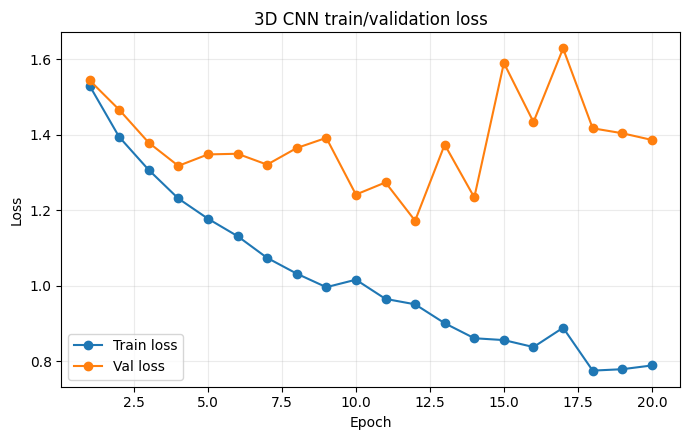

In [ ]:
plot_training_history(model, title="3D CNN train/validation loss");

,precision,recall,f1-score,support
Water,0.400000,0.75,0.521739,8.0
GABAAR_Antagonist,1.000000,0.25,0.400000,4.0
GABAAR_NegativeAllostericModulator,0.000000,0.00,0.000000,4.0
NMDAR_Activation,0.750000,0.75,0.750000,4.0
NMDAR_Antagonist,0.500000,0.50,0.500000,4.0
accuracy,0.500000,0.50,0.500000,0.5
macro avg,0.530000,0.45,0.434348,24.0
weighted avg,0.508333,0.50,0.448913,24.0


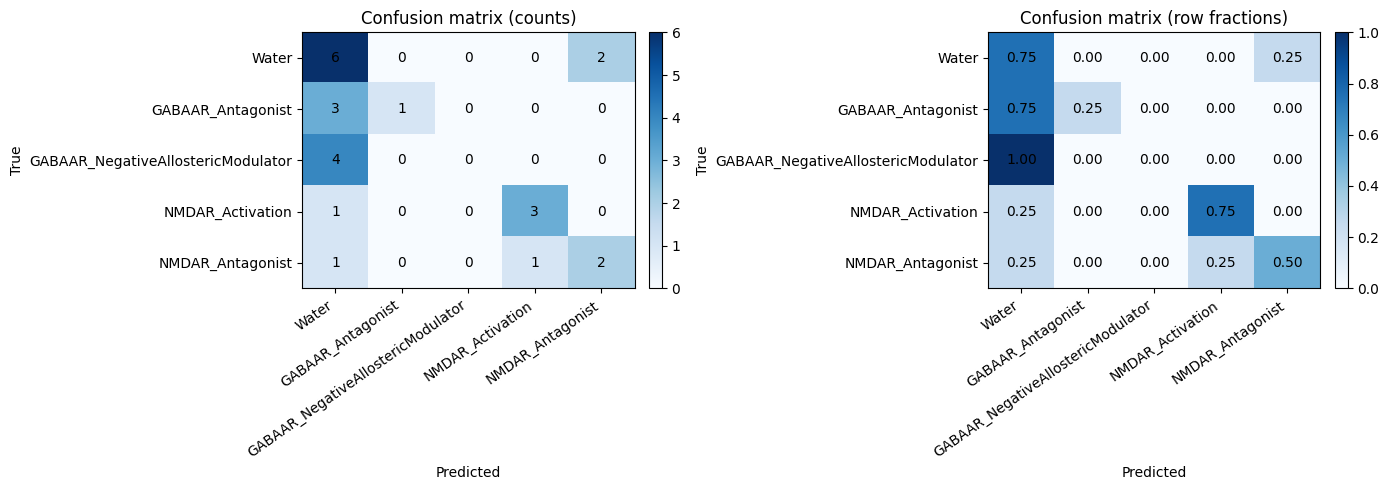

In [ ]:
holdout_pred = model.predict(X_holdout)
report_df = pd.DataFrame(
    classification_report(
        y_holdout,
        holdout_pred,
        labels=model.classes_,
        target_names=[dataset["label_map"][int(label)] for label in model.classes_],
        output_dict=True,
        zero_division=0,
    )
).T
display(report_df)
plot_confusion_matrices(
    y_holdout,
    holdout_pred,
    class_labels=model.classes_,
    label_map=dataset["label_map"],
);

/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


,embed_x,embed_y,label,label_name,method,mechanism_of_action,compound,concentration_band,concentration_label,image_condition_dir,augmentation_index,rotation_degrees,is_control
0,7.950695,8.602824,4,NMDAR_Antagonist,umap,NMDAR_Antagonist,Ketamine,low,15.625 uM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/FOURTH BATCH 2018/Ketamine Run 1 30 Jan 2018/15.625microM F5,0,0.0,False
1,10.012512,8.031460,2,GABAAR_NegativeAllostericModulator,umap,GABAAR_NegativeAllostericModulator,DMCM,low,0.25 mM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/FOURTH BATCH 2018/DMCM Run 2 6 Nov 2018 (poorly soluble)/0.25mM F2.3,0,0.0,False
2,7.106763,9.261223,3,NMDAR_Activation,umap,NMDAR_Activation,(RS)-(Tetrazol-5-yl)glycine,high,62.5 uM,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/FOURTH BATCH 2018/Rs tetrazol Glycine (RsT) Run 1 21 aug 2018/62.5microM F2 bright but heart beat good,0,0.0,False
3,8.481097,9.739721,0,Water,umap,GABAAR_NegativeAllostericModulator,DMCM,control,control,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/FOURTH BATCH 2018/DMCM Run 2 6 Nov 2018 (poorly soluble)/Water F2.2,0,0.0,True
4,9.626800,9.163125,0,Water,umap,GABAAR_Antagonist,Bemegride,control,control,/mnt/tyler/Matt Winter/BRAIN IMAGES BACKUP/THIRD BATCH convulsants/Bemegride run 2 7 6 17/wATER f2.4,0,0.0,True


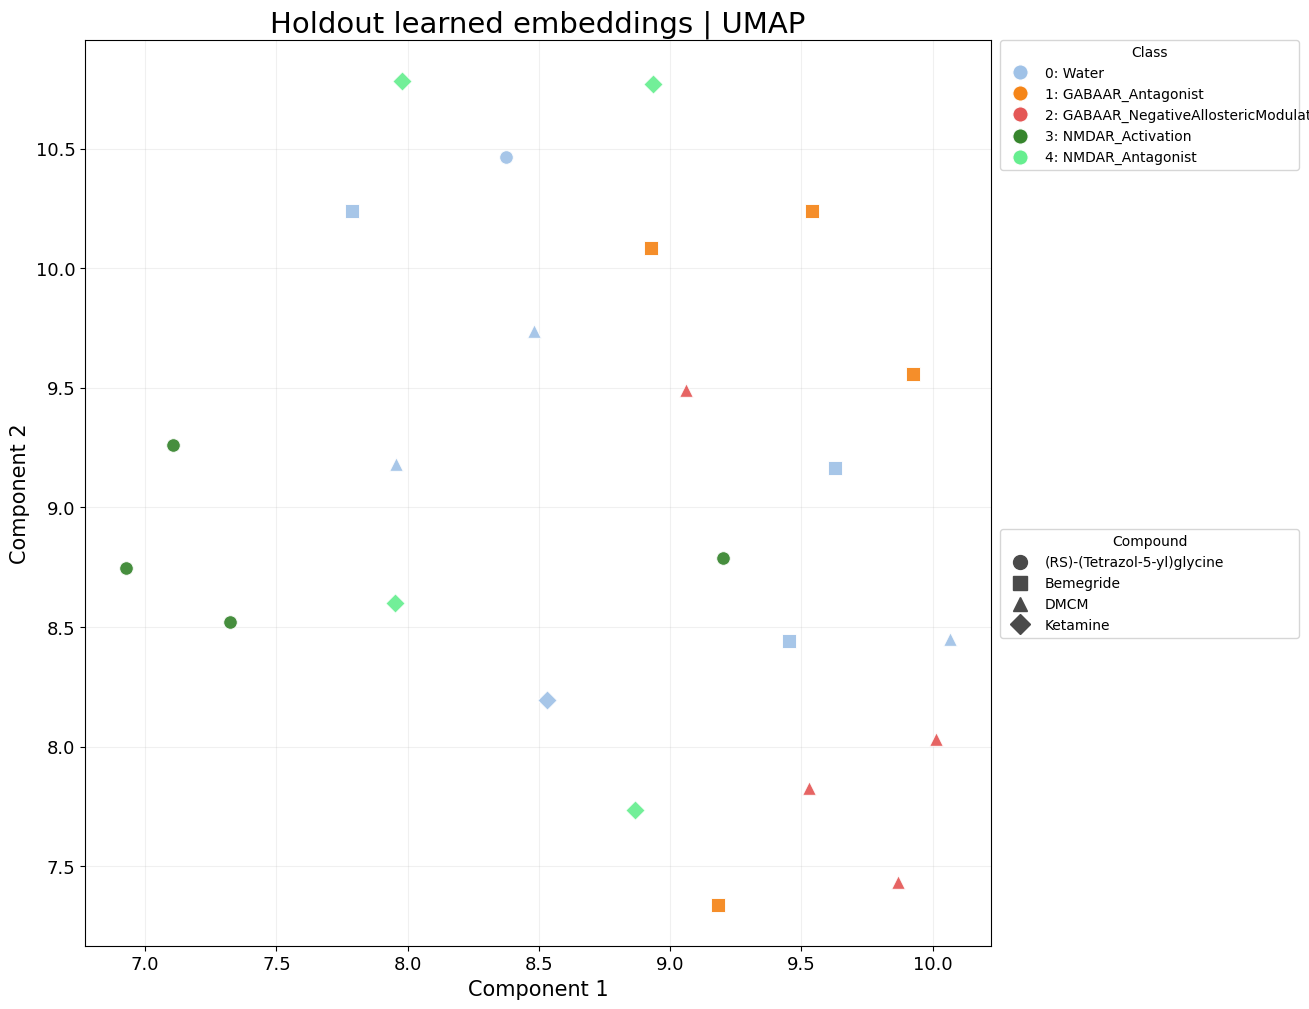

In [ ]:
holdout_embeddings = torch.from_numpy(model.transform(X_holdout))
holdout_embedding_df = build_tensor_embedding_2d(
    holdout_embeddings,
    y_holdout,
    label_map=dataset["label_map"],
    metadata=metadata_holdout,
    method=embedding_method,
    random_state=random_seed,
    umap_n_neighbors=umap_n_neighbors,
    umap_min_dist=umap_min_dist,
)
display(holdout_embedding_df.head(5))
plot_tensor_embedding_2d(
    holdout_embedding_df,
    title=f"Holdout learned embeddings | {embedding_method.upper()}",
    marker_column="compound",
    show_svm_background=True,
);